**Visualization**
- use matplotlib and use it to visualize the geographic distribution of the datacenters

In [89]:
import matplotlib.pyplot as plt #for visualization of spatial data
import pandas as pd #for data manipulation
import numpy as np #for numerical operations
import geopandas as gpd #for working with geospatial data
import geodatasets


ModuleNotFoundError: No module named 'geodatasets'

data = pd.read_csv("im3_atlas_cleaned.csv") # reading the cleaned csv file into a pandas dataframe
data.info()

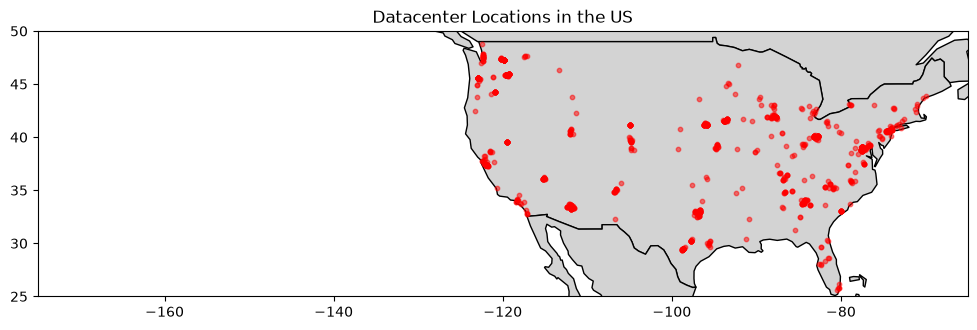

In [102]:
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['lon'], data['lat'])) # converting the pandas dataframe to a geopandas dataframe by creating a geometry column from the lat and lon columns
gdf.set_crs(epsg=4326, inplace=True) # setting the coordinate reference system to WGS84 (EPSG:4326)
# wgs84 since the data we've gotten is in that format (lon lat)
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip") # loading the world map from geopandas datasets
ax = world.plot(figsize=(12, 8), color='lightgrey', edgecolor='black') # plotting the world map

ax.set_xlim([-175, -65]) # setting the x limits to focus on the US
ax.set_ylim([25, 50]) # setting the y limits to focus on the US

gdf.plot(ax=ax, markersize=10, color='red', alpha=0.5) # plotting the datacenter locations on top of the world map
plt.title('Datacenter Locations in the US') # adding a title to the plot
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

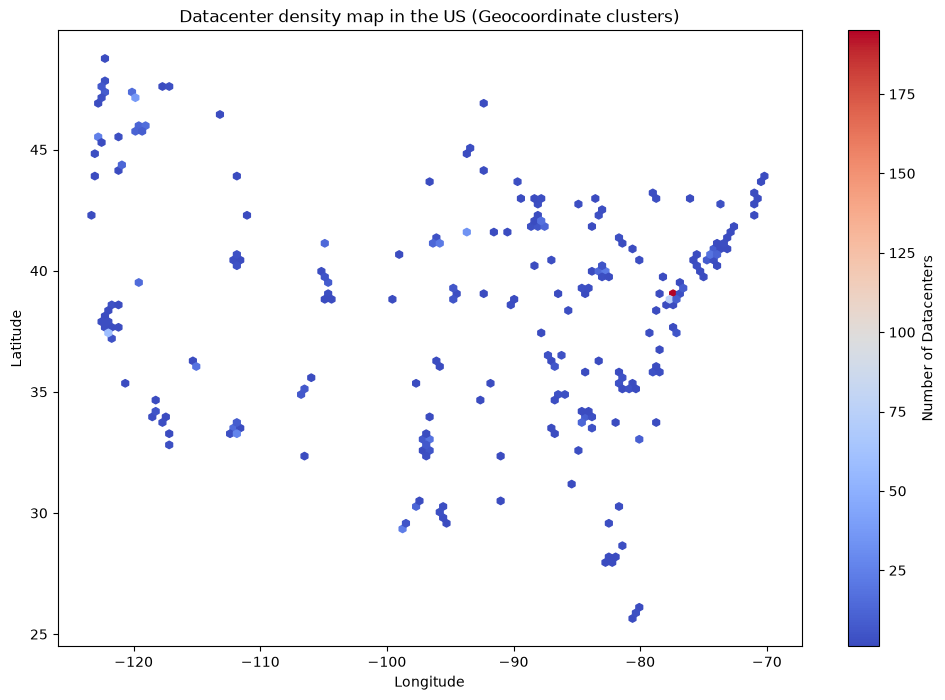

In [81]:
plt.figure(figsize=(12, 8))
hb = plt.hexbin(data['lon'], data['lat'], gridsize=(100,50), cmap='coolwarm',mincnt=1) #will create a plot with hexagonal bins, where the color of each bin represents the number of points in that bin
cb = plt.colorbar(hb,label = 'Number of Datacenters') #adding a color bar to the plot

plt.title('Datacenter density map in the US (Geocoordinate clusters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show


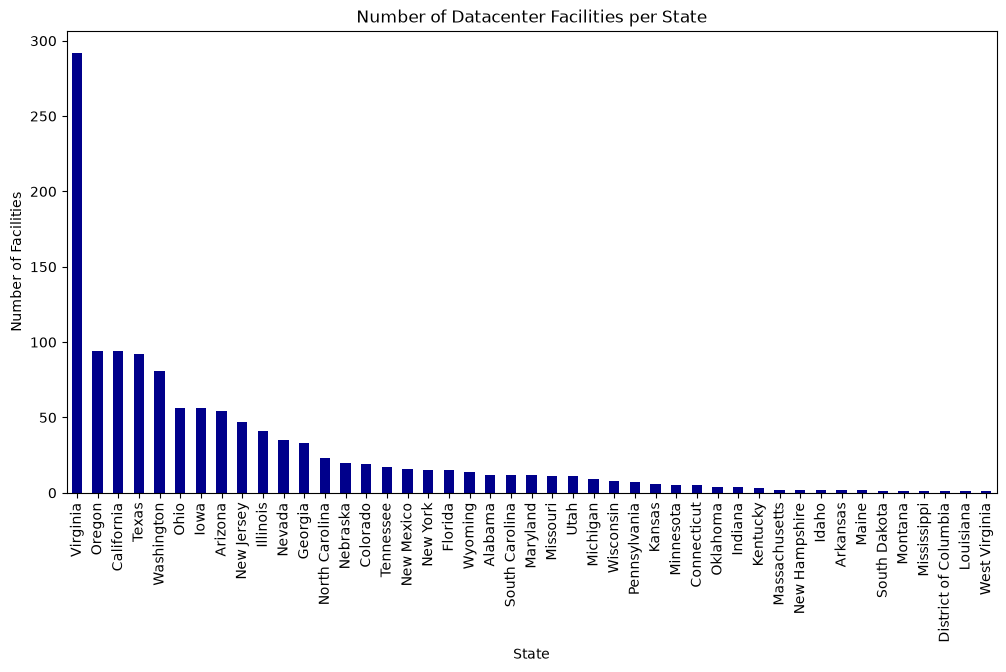

In [78]:
plt.figure(figsize=(12,6))
state_counts = data['state'].value_counts().sort_values(ascending=False)
state_counts.plot(kind='bar', color = 'darkblue')
plt.title('Number of Datacenter Facilities per State')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.show()
